# Deteccion de Tumores (Benigno vs Maligno) con Red Neuronal - Dataset sklearn

## Paso 1: Importar librerias

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# ===== CONFIGURAR SEMILLAS PARA REPRODUCIBILIDAD =====
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"\n✓ Semillas aleatorias configuradas (SEED={SEED})")

TensorFlow: 2.21.0
Pandas: 3.0.1
NumPy: 2.4.3

✓ Semillas aleatorias configuradas (SEED=42)


## Paso 2: Cargar y validar dataset desde sklearn

In [64]:
breast = load_breast_cancer()

X_df = pd.DataFrame(breast.data, columns=breast.feature_names)
y_original = pd.Series(breast.target, name='target_original')

# En sklearn: 0=malignant, 1=benign. Lo invertimos para mantener: 0=Benigno, 1=Maligno
y = 1 - y_original

df = X_df.copy()
df['target'] = y.astype(int)
df['diagnosis'] = df['target'].map({0: 'B', 1: 'M'})

feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

if df['target'].isna().any():
    raise ValueError('Se detectaron valores nulos en target')

print('Dataset sklearn cargado correctamente')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Features usadas: {len(feature_cols)}")
print('Mapeo target: 0=Benigno, 1=Maligno')

df.head()

Dataset sklearn cargado correctamente
Filas: 569
Columnas: 32
Features usadas: 30
Mapeo target: 0=Benigno, 1=Maligno


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,M


## Paso 3: Limpieza de datos

In [65]:
print('=== Limpieza de datos ===\n')

# Verificar duplicados
duplicados_antes = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados_antes}")

if duplicados_antes > 0:
    df = df.drop_duplicates()
    print(f"  -> Eliminadas {duplicados_antes} filas duplicadas")

# Verificar valores nulos
nulos_por_columna = df.isnull().sum()
nulos_totales = nulos_por_columna.sum()
print(f"\nValores nulos por columna: {nulos_totales}")

if nulos_totales > 0:
    print("\nColumnas con valores nulos:")
    print(nulos_por_columna[nulos_por_columna > 0])
    
    # Opción 1: Eliminar filas con nulos (si son pocos)
    if nulos_totales < len(df) * 0.05:  # menos del 5%
        df = df.dropna()
        print(f"  -> Eliminadas filas con valores nulos")
    else:
        # Opción 2: Imputar con la mediana (para features numéricas)
        for col in feature_cols:
            if df[col].isnull().sum() > 0:
                mediana = df[col].median()
                df[col].fillna(mediana, inplace=True)
                print(f"  -> Imputados valores nulos en '{col}' con mediana: {mediana:.4f}")

# Verificar outliers extremos usando IQR
print(f"\n=== Detección de outliers (método IQR) ===")
outliers_totales = 0

for col in feature_cols[:5]:  # Revisar las primeras 5 features como ejemplo
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # factor 3 para outliers extremos
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers extremos detectados")
        outliers_totales += outliers

if outliers_totales == 0:
    print("No se detectaron outliers extremos en las features principales")

print(f"\n=== Dataset después de limpieza ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

# Actualizar feature_cols en caso de que se hayan eliminado columnas
feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

=== Limpieza de datos ===

Filas duplicadas encontradas: 0

Valores nulos por columna: 0

=== Detección de outliers (método IQR) ===
mean radius: 1 outliers extremos detectados
mean texture: 1 outliers extremos detectados
mean area: 5 outliers extremos detectados
mean smoothness: 1 outliers extremos detectados

=== Dataset después de limpieza ===
Filas: 569
Columnas: 32
Valores nulos restantes: 0


## Paso 4: Normalización de datos

=== Normalización de datos ===

Normalización aplicada a 30 features

Rango de valores después de normalización:
  Mínimo: 0.0000
  Máximo: 1.0000
  Media: 0.2389


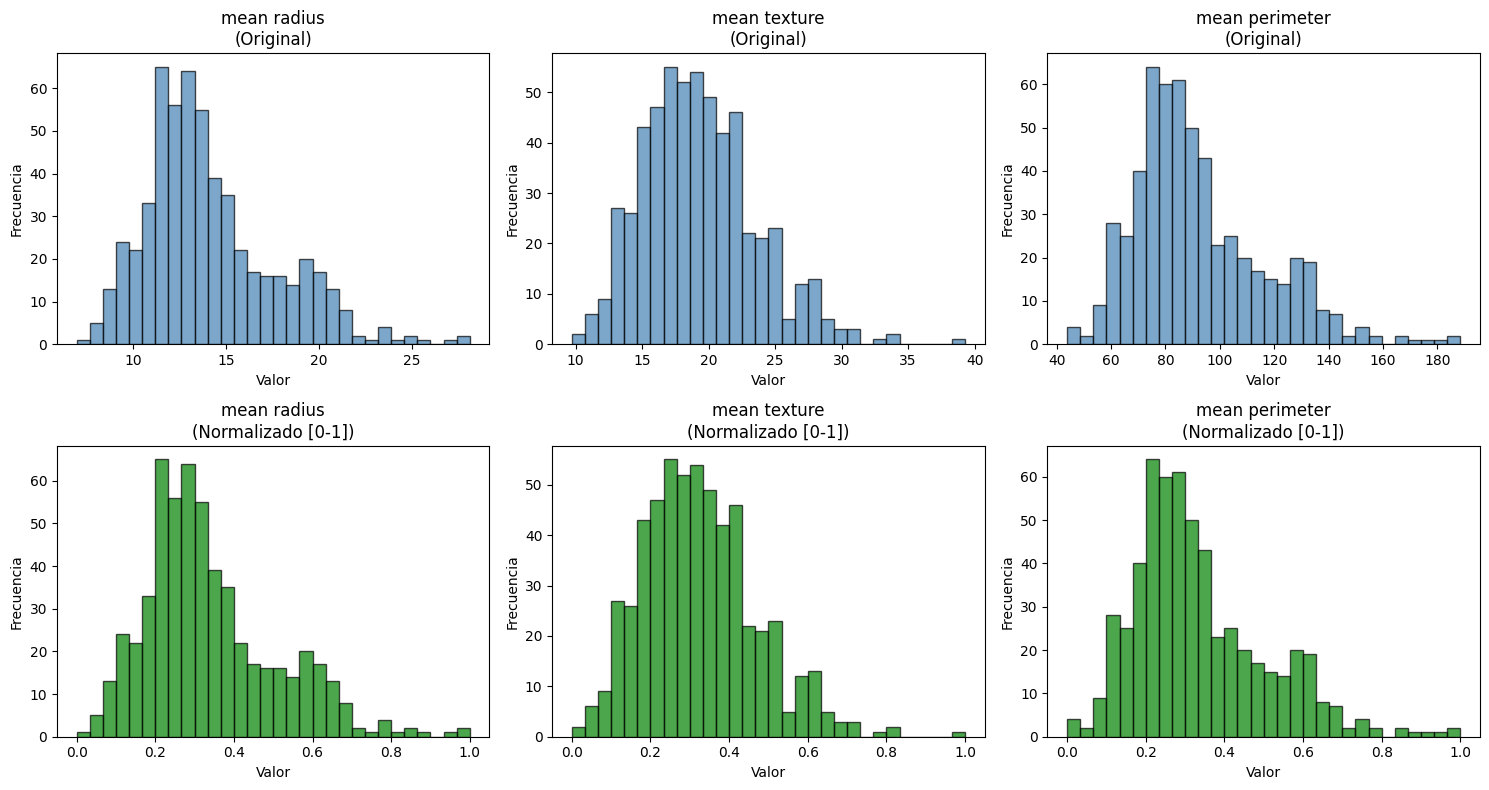


=== Dataset normalizado ===
Filas: 569
Features normalizadas: 30


In [66]:
print('=== Normalización de datos ===\n')

# Normalizar las features numéricas al rango [0, 1]
normalizer = MinMaxScaler()

# Normalizar solo las columnas de features (no diagnosis ni target)
df_normalized = df.copy()
df_normalized[feature_cols] = normalizer.fit_transform(df[feature_cols])

print(f"Normalización aplicada a {len(feature_cols)} features")
print(f"\nRango de valores después de normalización:")
print(f"  Mínimo: {df_normalized[feature_cols].min().min():.4f}")
print(f"  Máximo: {df_normalized[feature_cols].max().max():.4f}")
print(f"  Media: {df_normalized[feature_cols].mean().mean():.4f}")

# Visualizar comparación antes y después (primeras 3 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(feature_cols[:3]):
    # Antes de normalizar
    axes[0, idx].hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{col}\n(Original)')
    axes[0, idx].set_xlabel('Valor')
    axes[0, idx].set_ylabel('Frecuencia')
    
    # Después de normalizar
    axes[1, idx].hist(df_normalized[col], bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(f'{col}\n(Normalizado [0-1])')
    axes[1, idx].set_xlabel('Valor')
    axes[1, idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Actualizar el DataFrame principal con los datos normalizados
df = df_normalized.copy()

print(f"\n=== Dataset normalizado ===")
print(f"Filas: {df.shape[0]}")
print(f"Features normalizadas: {len(feature_cols)}")

## Paso 5: Analisis exploratorio rapido

Valores nulos totales: 0
Benigno (0): 357
Maligno (1): 212


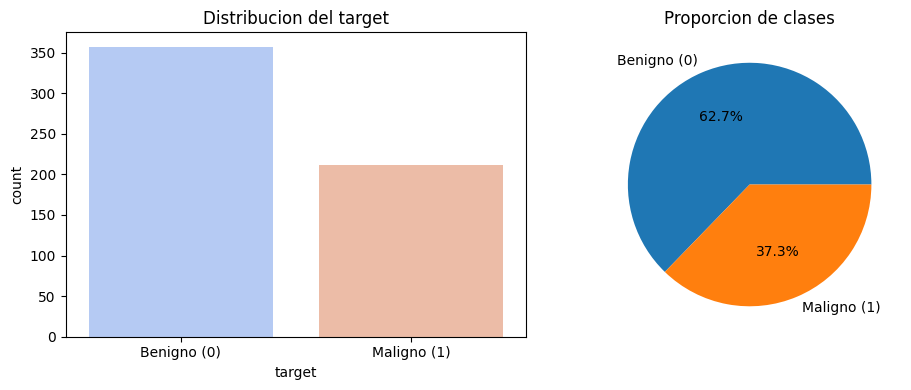

In [67]:
print('Valores nulos totales:', df.isnull().sum().sum())

conteo = df['target'].value_counts().sort_index()
print(f"Benigno (0): {conteo.get(0, 0)}")
print(f"Maligno (1): {conteo.get(1, 0)}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, hue='target', palette='coolwarm', legend=False)
plt.title('Distribucion del target')
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])

plt.subplot(1, 2, 2)
df['target'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', labels=['Benigno (0)', 'Maligno (1)'])
plt.ylabel('')
plt.title('Proporcion de clases')

plt.tight_layout()
plt.show()

## Paso 6: Preprocesamiento (train/val/test estratificado)

In [68]:
X = df[feature_cols].copy()
y = df['target'].copy()

# Los datos ya están normalizados en el rango [0,1] del Paso 4
print('Datos ya normalizados - Rango de valores:')
print(f"  Mínimo: {X.min().min():.4f}")
print(f"  Máximo: {X.max().max():.4f}\n")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# Convertir a numpy arrays (los datos ya están normalizados, no se necesita StandardScaler)
X_train_scaled = X_train.to_numpy()
X_val_scaled = X_val.to_numpy()
X_test_scaled = X_test.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

print('\nDatos preparados para entrenamiento')
print(f"Media train: {X_train_scaled.mean():.4f}")
print(f"Std train: {X_train_scaled.std():.4f}")
print(f"Rango: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")

Datos ya normalizados - Rango de valores:
  Mínimo: 0.0000
  Máximo: 1.0000

Train: (364, 30), Validation: (91, 30), Test: (114, 30)

Datos preparados para entrenamiento
Media train: 0.2397
Std train: 0.1755
Rango: [0.0000, 1.0000]


## Paso 7: Crear y entrenar la red neuronal

In [69]:
num_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(num_features,)),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dropout(0.10),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

print('Entrenamiento finalizado')
print(f"Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - accuracy: 0.6264 - loss: 0.6842 - val_accuracy: 0.6374 - val_loss: 0.6710
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6703 - loss: 0.6592 - val_accuracy: 0.6813 - val_loss: 0.6466
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6951 - loss: 0.6340 - val_accuracy: 0.7143 - val_loss: 0.6129
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7363 - loss: 0.5988 - val_accuracy: 0.7802 - val_loss: 0.5673
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7665 - loss: 0.5668 - val_accuracy: 0.8681 - val_loss: 0.5079
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7912 - loss: 0.5261 - val_accuracy: 0.8901 - val_loss: 0.4487
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8379 - loss: 0.4727 - val_accuracy: 0.8901 - val_loss: 0.3906
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8352 - loss: 0.4236 - val_accuracy: 0

## Paso 8: Evaluacion del modelo

In [70]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1-score:  0.9630
ROC-AUC:   0.9967

Reporte de clasificacion:
              precision    recall  f1-score   support

 Benigno (0)       0.96      1.00      0.98        72
 Maligno (1)       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



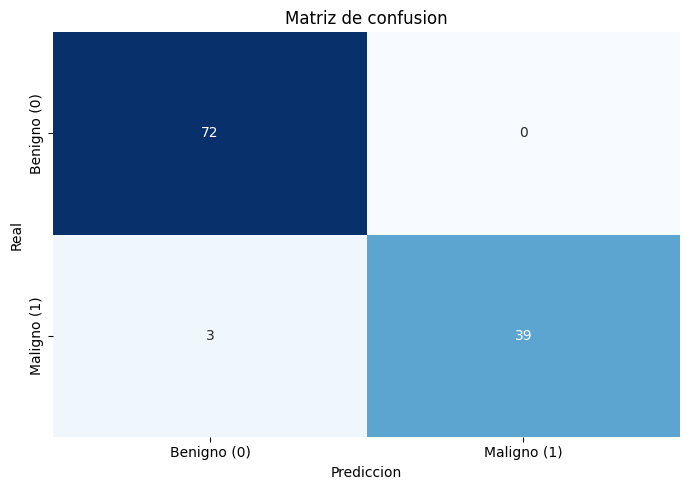

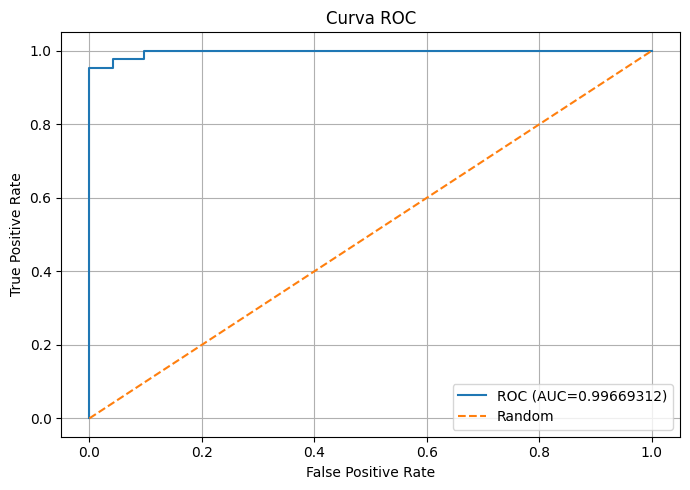

In [71]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.yticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.8f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Paso 9: Prediccion para nuevos parametros

In [72]:
TARGET_MAP = {0: 'Benigno', 1: 'Maligno'}

def predecir_tumor(parametros_entrada, modelo, normalizador, columnas_modelo, umbral=0.5):
    """
    parametros_entrada: dict con las 30 features del dataset sklearn.
    modelo: modelo de red neuronal entrenado
    normalizador: MinMaxScaler usado en el Paso 4 para normalizar datos
    columnas_modelo: lista de nombres de features
    umbral: umbral de clasificación (default 0.5)
    """
    faltantes = [c for c in columnas_modelo if c not in parametros_entrada]
    if faltantes:
        raise ValueError(f'Faltan parametros: {faltantes}')

    x_df = pd.DataFrame([parametros_entrada], columns=columnas_modelo)
    x_normalized = normalizador.transform(x_df)

    prob_maligno = float(modelo.predict(x_normalized, verbose=0).flatten()[0])
    prob_benigno = 1.0 - prob_maligno
    pred = 1 if prob_maligno >= umbral else 0

    return {
        'prob_maligno': prob_maligno,
        'prob_benigno': prob_benigno,
        'pred_clase': pred,
        'pred_etiqueta': TARGET_MAP[pred],
    }

# Ejemplo de uso con los promedios del dataset
PARAMETROS_USUARIO = X.mean().to_dict()

resultado = predecir_tumor(
    PARAMETROS_USUARIO,
    modelo=model,
    normalizador=normalizer,  # Usar el normalizador del Paso 4
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print('=== Resultado de prediccion ===')
print(f"Prob. maligno: {resultado['prob_maligno']:.4f}")
print(f"Prob. benigno: {resultado['prob_benigno']:.4f}")
print(f"Clase predicha: {resultado['pred_clase']} -> {resultado['pred_etiqueta']}")

=== Resultado de prediccion ===
Prob. maligno: 0.0000
Prob. benigno: 1.0000
Clase predicha: 0 -> Benigno


In [73]:
# Diagnostico rapido de por que el modelo aprende
corr_abs = df[feature_cols + ['target']].corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

print('Top 10 correlaciones absolutas con target:')
print(corr_abs.head(10))
print(f'\nCorrelacion maxima abs: {corr_abs.max():.4f}')
print(f'Correlacion media abs: {corr_abs.mean():.4f}')

print('\nDistribucion de clases en dataset completo:')
print(df['target'].value_counts(normalize=True).sort_index())

print('\nValores minimos por feature (primeras 10):')
print(df[feature_cols].min().head(10))

Top 10 correlaciones absolutas con target:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64

Correlacion maxima abs: 0.7936
Correlacion media abs: 0.4703

Distribucion de clases en dataset completo:
target
0    0.627417
1    0.372583
Name: proportion, dtype: float64

Valores minimos por feature (primeras 10):
mean radius               0.0
mean texture              0.0
mean perimeter            0.0
mean area                 0.0
mean smoothness           0.0
mean compactness          0.0
mean concavity            0.0
mean concave points       0.0
mean symmetry             0.0
mean fractal dimension    0.0
dtype: float64


## Paso 10: Ingresar datos personalizados

In [74]:
# Mostrar rangos de referencia del dataset original (antes de normalizar)
print("=" * 70)
print("RANGOS DE REFERENCIA (valores del dataset original)")
print("=" * 70)

# Cargar dataset original para mostrar rangos reales
breast_ref = load_breast_cancer()
df_ref = pd.DataFrame(breast_ref.data, columns=breast_ref.feature_names)

print(f"\n{'Feature':<30} {'Min':>12} {'Max':>12} {'Promedio':>12}")
print("-" * 70)
for col in feature_cols:
    print(f"{col:<30} {df_ref[col].min():>12.4f} {df_ref[col].max():>12.4f} {df_ref[col].mean():>12.4f}")

print("\n" + "=" * 70)

RANGOS DE REFERENCIA (valores del dataset original)

Feature                                 Min          Max     Promedio
----------------------------------------------------------------------
mean radius                          6.9810      28.1100      14.1273
mean texture                         9.7100      39.2800      19.2896
mean perimeter                      43.7900     188.5000      91.9690
mean area                          143.5000    2501.0000     654.8891
mean smoothness                      0.0526       0.1634       0.0964
mean compactness                     0.0194       0.3454       0.1043
mean concavity                       0.0000       0.4268       0.0888
mean concave points                  0.0000       0.2012       0.0489
mean symmetry                        0.1060       0.3040       0.1812
mean fractal dimension               0.0500       0.0974       0.0628
radius error                         0.1115       2.8730       0.4052
texture error                       

DATOS INGRESADOS
  mean radius: 14.127
  mean texture: 19.289
  mean perimeter: 91.969
  mean area: 654.889
  mean smoothness: 0.096
  mean compactness: 0.104
  mean concavity: 0.089
  mean concave points: 0.049
  mean symmetry: 0.181
  mean fractal dimension: 0.063
  radius error: 0.405
  texture error: 1.217
  perimeter error: 2.866
  area error: 40.337
  smoothness error: 0.007
  compactness error: 0.025
  concavity error: 0.032
  concave points error: 0.012
  symmetry error: 0.021
  fractal dimension error: 0.004
  worst radius: 16.269
  worst texture: 25.677
  worst perimeter: 107.261
  worst area: 880.583
  worst smoothness: 0.132
  worst compactness: 0.254
  worst concavity: 0.272
  worst concave points: 0.115
  worst symmetry: 0.29
  worst fractal dimension: 0.084

RESULTADO DE LA PREDICCION

  Probabilidad de BENIGNO:  69.99%
  Probabilidad de MALIGNO:  30.01%

  >>> DIAGNOSTICO: BENIGNO <<<



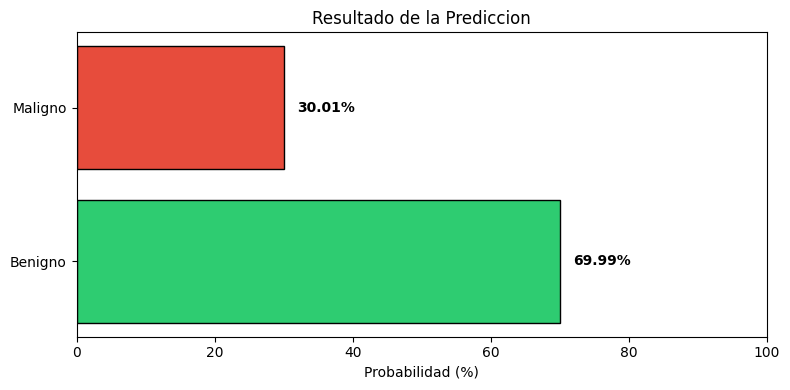

In [75]:
# Modifica los valores segun tus mediciones.
# Los valores por defecto son los promedios del dataset.

MIS_DATOS = {
    # ----- MEDIDAS MEAN (promedio de las celulas) -----
    'mean radius':             14.127,    # Radio promedio
    'mean texture':            19.289,    # Textura promedio
    'mean perimeter':          91.969,    # Perimetro promedio
    'mean area':               654.889,   # Area promedio
    'mean smoothness':         0.096,     # Suavidad promedio
    'mean compactness':        0.104,     # Compacidad promedio
    'mean concavity':          0.089,     # Concavidad promedio
    'mean concave points':     0.049,     # Puntos concavos promedio
    'mean symmetry':           0.181,     # Simetria promedio
    'mean fractal dimension':  0.063,     # Dimension fractal promedio
    
    # ----- MEDIDAS SE (error estandar) -----
    'radius error':            0.405,     # Error del radio
    'texture error':           1.217,     # Error de textura
    'perimeter error':         2.866,     # Error del perimetro
    'area error':              40.337,    # Error del area
    'smoothness error':        0.007,     # Error de suavidad
    'compactness error':       0.025,     # Error de compacidad
    'concavity error':         0.032,     # Error de concavidad
    'concave points error':    0.012,     # Error de puntos concavos
    'symmetry error':          0.021,     # Error de simetria
    'fractal dimension error': 0.004,     # Error de dimension fractal
    
    # ----- MEDIDAS WORST (peor valor / mas grande) -----
    'worst radius':            16.269,    # Peor radio
    'worst texture':           25.677,    # Peor textura
    'worst perimeter':         107.261,   # Peor perimetro
    'worst area':              880.583,   # Peor area
    'worst smoothness':        0.132,     # Peor suavidad
    'worst compactness':       0.254,     # Peor compacidad
    'worst concavity':         0.272,     # Peor concavidad
    'worst concave points':    0.115,     # Peor puntos concavos
    'worst symmetry':          0.290,     # Peor simetria
    'worst fractal dimension': 0.084,     # Peor dimension fractal
}

# ============================================================================
# EJECUTAR PREDICCION
# ============================================================================

print("=" * 70)
print("DATOS INGRESADOS")
print("=" * 70)
for key, value in MIS_DATOS.items():
    print(f"  {key}: {value}")

# Realizar prediccion
resultado = predecir_tumor(
    MIS_DATOS,
    modelo=model,
    normalizador=normalizer,
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print("\n" + "=" * 70)
print("RESULTADO DE LA PREDICCION")
print("=" * 70)
print(f"\n  Probabilidad de BENIGNO:  {resultado['prob_benigno']*100:.2f}%")
print(f"  Probabilidad de MALIGNO:  {resultado['prob_maligno']*100:.2f}%")
print(f"\n  >>> DIAGNOSTICO: {resultado['pred_etiqueta'].upper()} <<<")
print("\n" + "=" * 70)

# Visualizacion
fig, ax = plt.subplots(figsize=(8, 4))
categorias = ['Benigno', 'Maligno']
probabilidades = [resultado['prob_benigno']*100, resultado['prob_maligno']*100]
colores = ['#2ecc71', '#e74c3c']

bars = ax.barh(categorias, probabilidades, color=colores, edgecolor='black')
ax.set_xlim(0, 100)
ax.set_xlabel('Probabilidad (%)')
ax.set_title('Resultado de la Prediccion')

for bar, prob in zip(bars, probabilidades):
    ax.text(prob + 2, bar.get_y() + bar.get_height()/2, f'{prob:.2f}%', 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()